In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = np.array( #虛構二維灰階圖片
    [[10,20,30,40,50],
    [15,25,35,45,55],
    [12,22,32,42,52],
    [18,28,38,48,58],
    [11,21,31,41,51]]
)
filter_kernel = np.array( #卷積層 3*3過濾器
    [[0,1,0],
     [0,1,0],
     [0,1,0]]
)

In [3]:
image_height , image_width = image.shape
filter_height, filter_width = filter_kernel.shape
ouput_height = image_height - filter_height +1
ouput_width = image_width - filter_width +1
feature_map = np.zeros((ouput_height, ouput_width))

In [5]:
for i in range(ouput_height):
    for j in range(ouput_width):
        image_patch = image[i: i+filter_height, j: j+filter_width]
        feature_map[i, j] = np.sum(image_patch * filter_kernel)
print(feature_map)

[[ 67.  97. 127.]
 [ 75. 105. 135.]
 [ 71. 101. 131.]]


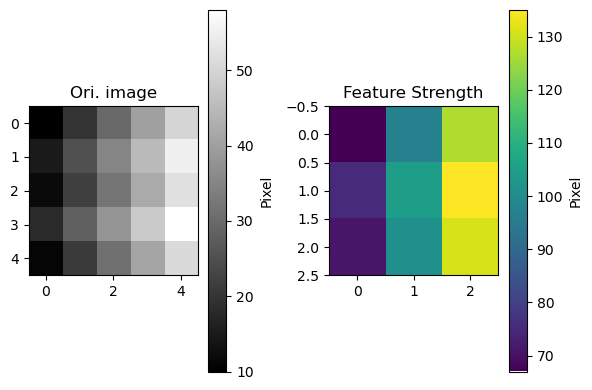

In [9]:
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Ori. image')
plt.colorbar(label='Pixel')

plt.subplot(1,2,2)
plt.imshow(feature_map, cmap='viridis')
plt.title('Feature Strength')
plt.colorbar(label='Pixel')
plt.tight_layout()
plt.show()

In [15]:
pool_size = (2,2)
stride = 1
print(image)
print(f"池化窗口:{pool_size[0]}*{pool_size[1]}, 步幅: {stride}")

[[10 20 30 40 50]
 [15 25 35 45 55]
 [12 22 32 42 52]
 [18 28 38 48 58]
 [11 21 31 41 51]]
池化窗口:2*2, 步幅: 1


In [16]:
input_height, input_width = image.shape
pool_height, pool_width = pool_size
ouput_pool_height = (input_height - pool_height) // stride + 1
ouput_pool_width = (input_width - pool_width) // stride + 1
pool_feature_map = np.zeros((ouput_pool_height, ouput_pool_width))

In [17]:
for i in range(ouput_pool_height):
    for j in range(ouput_pool_width):
        start_row = i * stride
        end_row = start_row + pool_height
        start_col = j * stride
        end_col = start_col + pool_width
        pool_patch = image[start_row: end_row, start_col:end_col]
        pool_feature_map[i ,j] = np.max(pool_patch)
print(pool_feature_map)

[[25. 35. 45. 55.]
 [25. 35. 45. 55.]
 [28. 38. 48. 58.]
 [28. 38. 48. 58.]]


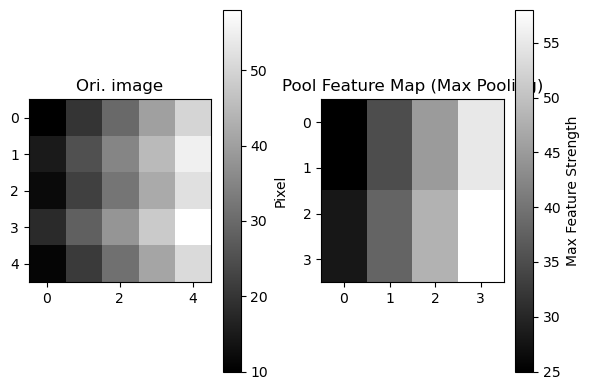

In [18]:
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Ori. image')
plt.colorbar(label='Pixel')

plt.subplot(1,2,2)
plt.imshow(pool_feature_map, cmap='gray')
plt.title('Pool Feature Map (Max Pooling)')
plt.colorbar(label='Max Feature Strength')
plt.tight_layout()
plt.show()

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import numpy as np

In [48]:
(train_images, train_labels),(test_images, test_labels)=datasets.cifar10.load_data()
train_images, test_images = train_images/255.0, test_images/255.0
class_name = ['airplane','automobile','bird','cat','deer','dog', 'frog' ,'horse','ship','truck']
print(f"訓練圖片資料結構:{train_images.shape}")
print(f"測試圖片資料結構:{test_images.shape}")
print(f"類別數量:{len(class_name)}")

訓練圖片資料結構:(50000, 32, 32, 3)
測試圖片資料結構:(10000, 32, 32, 3)
類別數量:10


In [49]:
#建立CNN
model = models.Sequential()
model.add(Input(shape=(32,32,3)))
model.add(layers.Conv2D(16,(5,5),  padding='same', activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(32,(5,5),  padding='same', activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Flatten())



model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,610 (1.06 MB)

 Trainable params: 277,610 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#編譯模型
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#訓練模型
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4776 - loss: 1.4600 - val_accuracy: 0.5833 - val_loss: 1.1730
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6123 - loss: 1.1051 - val_accuracy: 0.6269 - val_loss: 1.0639
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6636 - loss: 0.9558 - val_accuracy: 0.6432 - val_loss: 1.0178
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7017 - loss: 0.8566 - val_accuracy: 0.6670 - val_loss: 0.9625
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7283 - loss: 0.7713 - val_accuracy: 0.6698 - val_loss: 0.9644
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7565 - loss: 0.6921 - val_accuracy: 0.6671 - val_loss: 0.9921
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7811 - loss: 0.6170 - val_accuracy: 0.6758 - val_loss: 1.0046
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8065 - loss: 0.5492 - 

In [51]:
#訓練模型
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8667 - loss: 0.3739 - val_accuracy: 0.6721 - val_loss: 1.2676
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8841 - loss: 0.3259 - val_accuracy: 0.6676 - val_loss: 1.3643
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8959 - loss: 0.2890 - val_accuracy: 0.6707 - val_loss: 1.4314
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9125 - loss: 0.2472 - val_accuracy: 0.6701 - val_loss: 1.5406
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9220 - loss: 0.2199 - val_accuracy: 0.6591 - val_loss: 1.7678
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9308 - loss: 0.1939 - val_accuracy: 0.6571 - val_loss: 1.8747
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9344 - loss: 0.1823 - val_accuracy: 0.6602 - val_loss: 1.9176
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9426 - loss: 0.1627 - 

In [52]:
#評估模型+視覺化
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(test_loss, test_acc)

313/313 - 0s - 2ms/step - accuracy: 0.6522 - loss: 2.2698
2.2697665691375732 0.6521999835968018


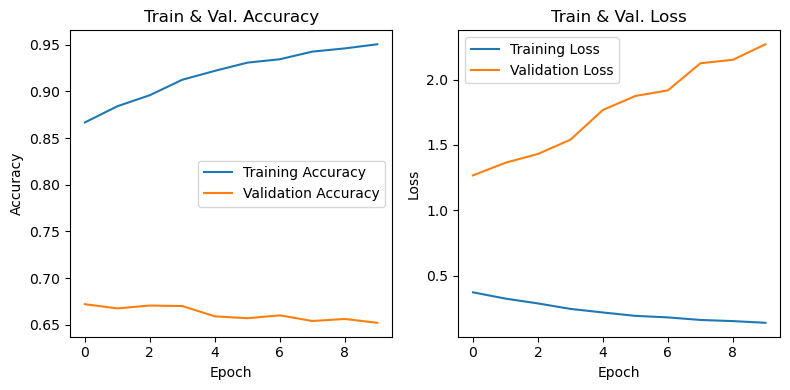

In [53]:
#視覺化
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train & Val. Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Val. Loss')
plt.legend()
plt.tight_layout()
plt.show()

練習題1:修改卷積層與池化層參數
修改上述CNN範例中的模型架構:
1.將第一個卷積層的filter數量增加到32，並將kernel_size改為(3,3)
2.將第二個卷積層filter數量增加到64。
3.將所有MaxPooling2D層的pool_size改為(3,3)
4.訓練模型5個epochs，並觀察訓練結果與原始模型的差異
請提供完整的程式碼，並在程式碼中註解您修改的部分

In [59]:
#建立CNN
model = models.Sequential()
model.add(Input(shape=(32,32,3)))
model.add(layers.Conv2D(32,(3,3),  padding='same', activation='relu'))
model.add(layers.MaxPooling2D(3,3))
model.add(layers.Conv2D(64,(5,5),  padding='same', activation='relu'))
model.add(layers.MaxPooling2D(3,3))
model.add(layers.Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,306 (497.29 KB)

 Trainable params: 127,306 (497.29 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
#編譯模型
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#訓練模型
history_ex1 = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8033 - loss: 0.5559 - val_accuracy: 0.7224 - val_loss: 0.8436
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8145 - loss: 0.5246 - val_accuracy: 0.7175 - val_loss: 0.8660
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8258 - loss: 0.4921 - val_accuracy: 0.7225 - val_loss: 0.8716
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8355 - loss: 0.4623 - val_accuracy: 0.7118 - val_loss: 0.9426
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8437 - loss: 0.4391 - val_accuracy: 0.7131 - val_loss: 0.9156
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8538 - loss: 0.4119 - val_accuracy: 0.7190 - val_loss: 0.9724
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8578 - loss: 0.3922 - val_accuracy: 0.7166 - val_loss: 0.9696
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8694 - loss: 0.3655 - 

練習題2:增加一層卷積層
在上述CNN範例模型的第二個池化層之後，再增加一個卷積層，其參數設定為filter=64,kernel_size=(3,3),activation='relu',padding='same'。
其他層的參數保持不變。
請提供完整的程式碼，並觀察新的模型架構隊訓練結果的影響

In [65]:
#建立CNN
model = models.Sequential()
model.add(Input(shape=(32,32,3)))
model.add(layers.Conv2D(32,(3,3),  padding='same', activation='relu'))
model.add(layers.MaxPooling2D(3,3))
model.add(layers.Conv2D(64,(5,5),  padding='same', activation='relu'))
model.add(layers.MaxPooling2D(3,3))
model.add(layers.Conv2D(64,(3,3),  padding='same', activation='relu'))
model.add(layers.Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,234 (641.54 KB)

 Trainable params: 164,234 (641.54 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
#編譯模型
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#訓練模型
history_ex1 = model.fit(train_images, train_labels, epochs=20, validation_data=(test_images, test_labels))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4523 - loss: 1.4915 - val_accuracy: 0.5540 - val_loss: 1.2514
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6114 - loss: 1.0941 - val_accuracy: 0.6162 - val_loss: 1.1243
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6680 - loss: 0.9424 - val_accuracy: 0.6814 - val_loss: 0.9139
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7019 - loss: 0.8412 - val_accuracy: 0.6961 - val_loss: 0.8732
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7339 - loss: 0.7600 - val_accuracy: 0.6920 - val_loss: 0.8990
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7527 - loss: 0.7054 - val_accuracy: 0.7086 - val_loss: 0.8552
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7684 - loss: 0.6486 - val_accuracy: 0.7012 - val_loss: 0.8763
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7867 - loss: 0.6036 - 

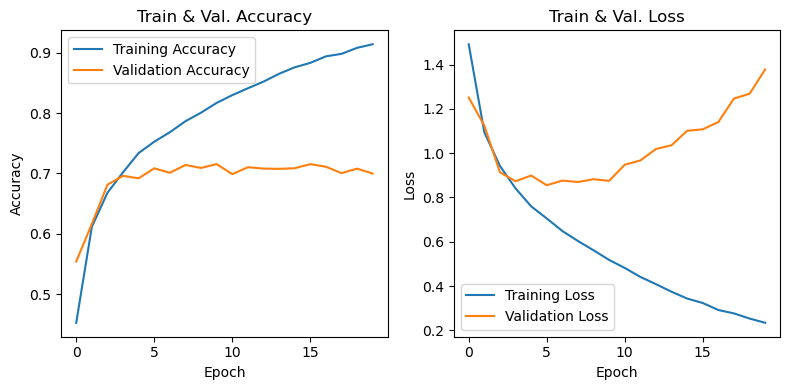

In [68]:
#視覺化
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history_ex1.history['accuracy'], label='Training Accuracy')
plt.plot(history_ex1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train & Val. Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ex1.history['loss'], label='Training Loss')
plt.plot(history_ex1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Val. Loss')
plt.legend()
plt.tight_layout()
plt.show()